Позаимствуем часть кода из версии без кластеризации:

In [77]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from find_similar import TimeSeriesSubsequenceSearcher

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

In [78]:
def parse_timestamp_column(values: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(values, errors="coerce")
    unit = "ms" if numeric.abs().max() >= 1e11 else "s"
    return pd.to_datetime(values, unit=unit, utc=True).dt.tz_convert(None)


def trim_last_weeks(df: pd.DataFrame, weeks: int = 6) -> pd.DataFrame:
    timestamps = parse_timestamp_column(df["timestamp"])
    cutoff = timestamps.max() - pd.Timedelta(weeks=weeks)
    return df.loc[timestamps >= cutoff].copy()


paths = sorted(Path(".").glob("time_series*.csv"))
series_dict = {path.stem: trim_last_weeks(pd.read_csv(path), weeks=6) for path in paths}

summary = pd.DataFrame(
    {
        "series_id": list(series_dict),
        "rows": [len(df) for df in series_dict.values()],
        "columns": [", ".join(df.columns) for df in series_dict.values()],
    }
)
summary

,series_id,rows,columns
0,time_series,9216,"timestamp, value_0"
1,time_series_2,1723,"timestamp, value, ground_truth, predicted"
2,time_series_3,1723,"timestamp, value, ground_truth, predicted"
3,time_series_4,1924,"timestamp, value, ground_truth, predicted"
4,time_series_5,1840,"timestamp, value, ground_truth, predicted"
5,time_series_6,1849,"timestamp, value, ground_truth, predicted"


In [79]:
searcher = TimeSeriesSubsequenceSearcher(
    freq="30min",
    agg="mean",
    interpolate_limit=3,
    normalize=True,
    exclusion_fraction=0.75,
)

searcher.fit(series_dict)

prepared_summary = pd.DataFrame(
    {
        "series_id": list(searcher.prepared_series_),
        "prepared_points": [len(series) for series in searcher.prepared_series_.values()],
        "missing": [int(series.isna().sum()) for series in searcher.prepared_series_.values()],
        "start": [series.index.min() for series in searcher.prepared_series_.values()],
        "end": [series.index.max() for series in searcher.prepared_series_.values()],
    }
)
prepared_summary

,series_id,prepared_points,missing,start,end
0,time_series,1536,0,2025-08-03 00:00:00,2025-09-03 23:30:00
1,time_series_2,2017,71,2025-07-22 17:00:00,2025-09-02 17:00:00
2,time_series_3,2017,71,2025-07-22 17:00:00,2025-09-02 17:00:00
3,time_series_4,2017,32,2025-07-22 21:30:00,2025-09-02 21:30:00
4,time_series_5,2017,60,2025-07-22 15:30:00,2025-09-02 15:30:00
5,time_series_6,2017,41,2025-07-22 13:00:00,2025-09-02 13:00:00


In [80]:
source_series_id = "time_series_2" if "time_series_2" in searcher.prepared_series_ else next(iter(searcher.prepared_series_))
query_points = 24  # 24 points * 30min = 12 hours

source_series = searcher.prepared_series_[source_series_id]
rolling_std = source_series.rolling(query_points).std().to_numpy()

if np.isfinite(rolling_std).any():
    query_end_idx = int(np.nanargmax(rolling_std))
    query_start_idx = query_end_idx - query_points + 1
else:
    query_start_idx = min(max(int(len(source_series) * 0.65), 0), len(source_series) - query_points)
    query_end_idx = query_start_idx + query_points - 1

query_start_idx = max(query_start_idx, 0)
query_end_idx = min(query_start_idx + query_points - 1, len(source_series) - 1)
query_start_time = source_series.index[query_start_idx]
query_end_time = source_series.index[query_end_idx]
query = source_series.iloc[query_start_idx : query_end_idx + 1]

query_start_time, query_end_time, len(query), float(query.std())

(Timestamp('2025-07-26 01:30:00'),
 Timestamp('2025-07-26 13:00:00'),
 24,
 132.7321319070093)

In [81]:
results = searcher.search_by_time_range(
    source_series_id=source_series_id,
    start_time=query_start_time,
    end_time=query_end_time,
    top_k=50,
    search_in_source=False,
)

results

,series_id,start_idx,end_idx,start_time,end_time,distance
0,time_series_3,161,184,2025-07-26 01:30:00,2025-07-26 13:00:00,0.000000
1,time_series_5,786,809,2025-08-08 00:30:00,2025-08-08 12:00:00,0.517902
2,time_series_3,1600,1623,2025-08-25 01:00:00,2025-08-25 12:30:00,0.635830
3,time_series_3,881,904,2025-08-10 01:30:00,2025-08-10 13:00:00,0.657821
4,time_series_5,834,857,2025-08-09 00:30:00,2025-08-09 12:00:00,0.686994
5,time_series_5,546,569,2025-08-03 00:30:00,2025-08-03 12:00:00,0.694709
6,time_series_5,1794,1817,2025-08-29 00:30:00,2025-08-29 12:00:00,0.701763
7,time_series_3,929,952,2025-08-11 01:30:00,2025-08-11 13:00:00,0.730510
8,time_series_3,1408,1431,2025-08-21 01:00:00,2025-08-21 12:30:00,0.733567
9,time_series_3,448,471,2025-08-01 01:00:00,2025-08-01 12:30:00,0.753770


/tmp/ipykernel_9217/994595730.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn_r')  # красный-жёлтый-зелёный (перевёрнутый: зелёный = малое расстояние)


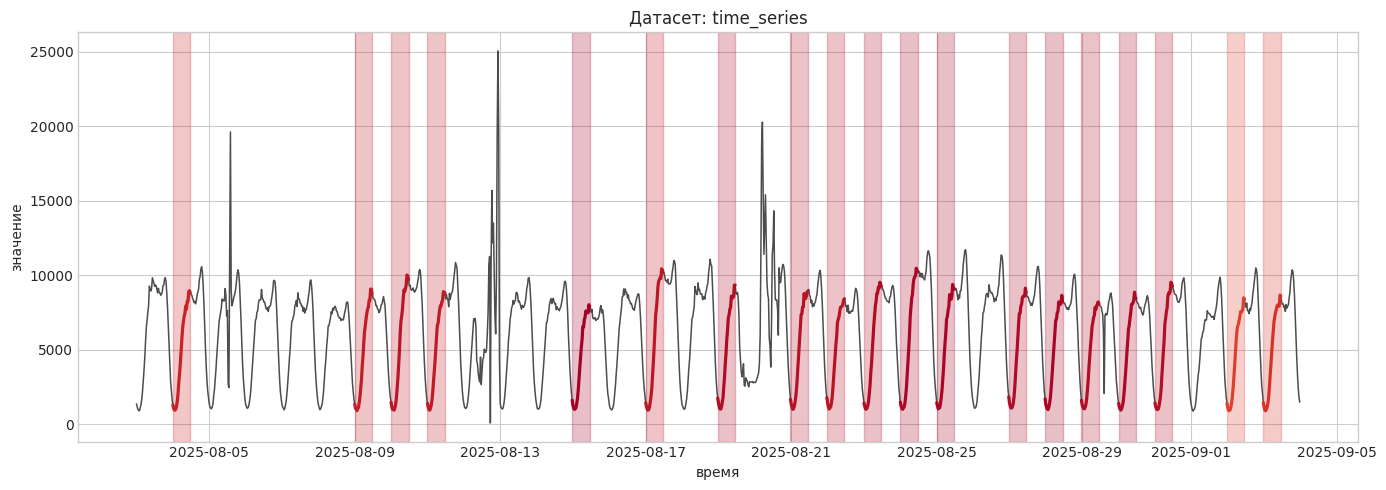

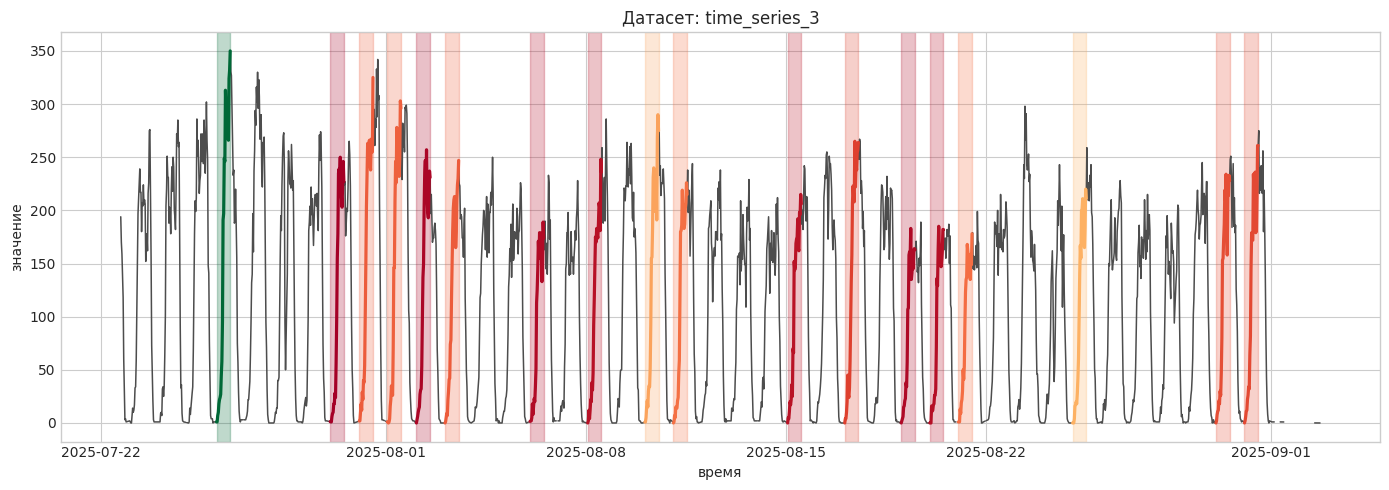

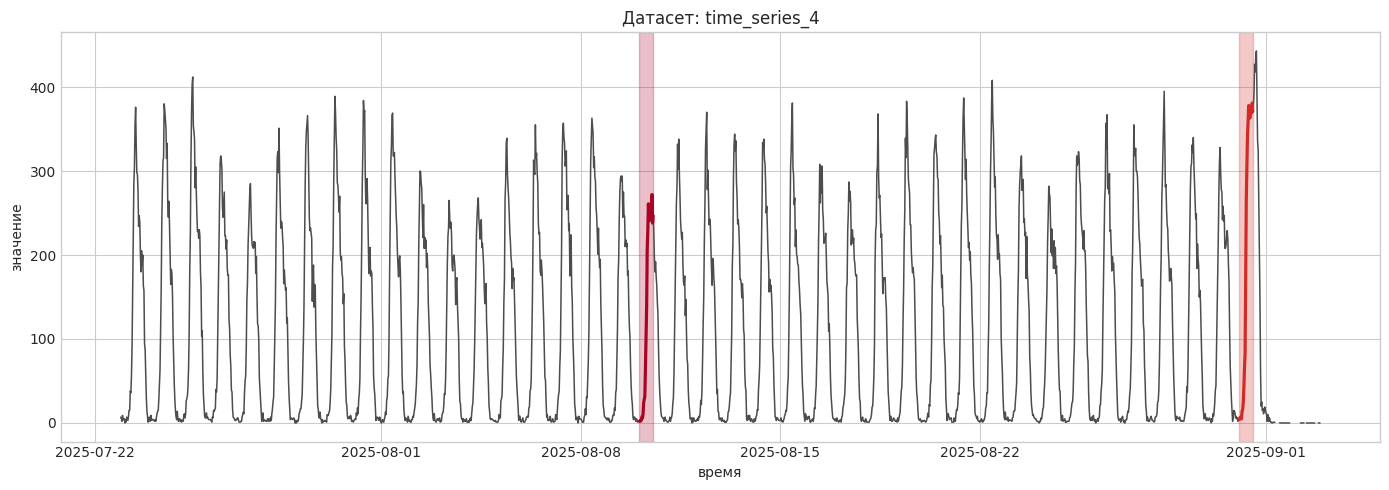

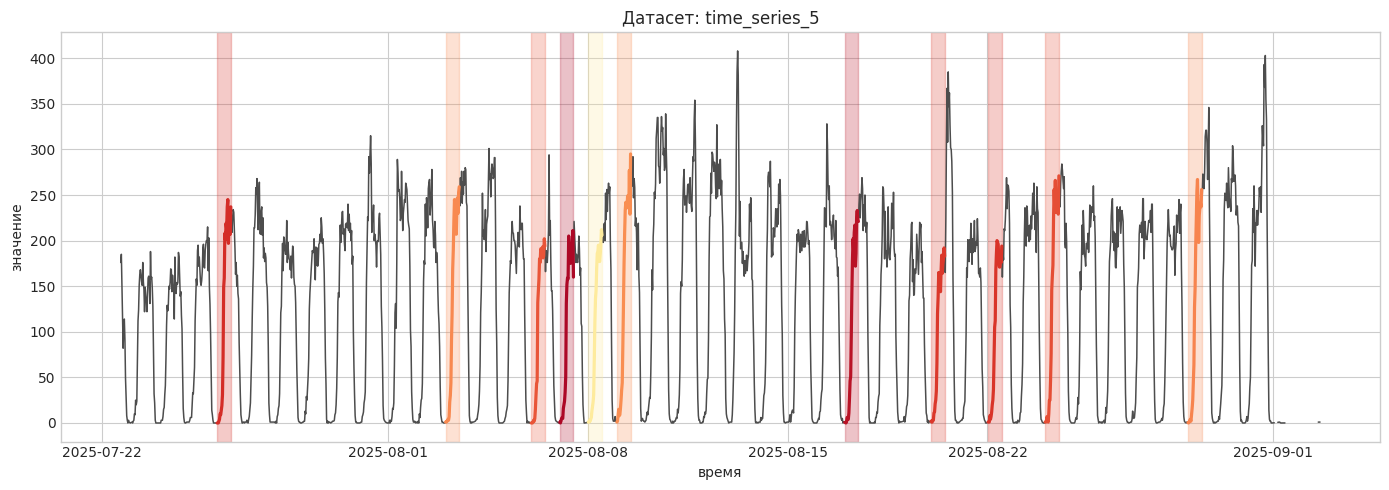

In [82]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

distances = results['distance'].values
norm = Normalize(vmin=distances.min(), vmax=distances.max())
cmap = cm.get_cmap('RdYlGn_r')  # красный-жёлтый-зелёный (перевёрнутый: зелёный = малое расстояние)

grouped = results.groupby('series_id')

# Для каждого датасета строим отдельный график
for series_id, group in grouped:
    # Получаем полный ряд датасета (подготовленный)
    full_series = searcher.prepared_series_[series_id]
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Рисуем весь ряд (серым, как контекст в оригинале)
    ax.plot(full_series.index, full_series.values, color='#4d4d4d', linewidth=1.1, label=f'Весь ряд {series_id}')
    
    # Для каждого сегмента в этом датасете рисуем выделение
    for idx, row in group.iterrows():
        segment = searcher.get_segment(row['series_id'], int(row['start_idx']), int(row['end_idx']))
        color = cmap(norm(row['distance']))
        # Заливка фона сегмента
        ax.axvspan(row['start_time'], row['end_time'], color=color, alpha=0.25)
        # Линия самого сегмента поверх фона
        ax.plot(segment.index, segment.values, color=color, linewidth=2.3,
                label=f'dist={row["distance"]:.4f} (idx {row["start_idx"]}:{row["end_idx"]})')
    
    
    ax.set_title(f'Датасет: {series_id}')
    ax.set_xlabel('время')
    ax.set_ylabel('значение')
    plt.tight_layout()
    plt.show()